# Import Packages.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('='*80)
print('Packages Imported.')
print('='*80)

Packages Imported.


# Load dataset and first look.

In [2]:
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# check the shape of the dataset
print(f"The data has {df.shape[0]} rows and {df.shape[1]} columns.")

The data has 9800 rows and 18 columns.


In [4]:
#check the name of the columns
print(f"\nThe name of the columns are\n {df.columns.tolist()}")


The name of the columns are
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [5]:
# Check the datatype of the columns
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [6]:
# Null counts.
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [7]:
# Statistical summary of the dataset.
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## Key Observations:
- The dataset has 8900 rows and 18 columns.
- Columns with null value is just 'Postal Code' with 11 null values.
- Most interesting columns for analysis are: 'Sales', 'Region', 'Category', 'Sub-Category'.

In [8]:
df.isnull().sum()[df.isnull().sum() > 0]

Postal Code    11
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [10]:
# Postal Code is not using for analysis therefore filling nulls with 'unknown'
df['Postal Code'] = df['Postal Code'].fillna('Unknown')


In [11]:
# Verify no null remains.
df.isnull().sum().sum()

np.int64(0)

In [12]:
df[df['Postal Code'] =='Unknown']

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,Unknown,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,Unknown,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,Unknown,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,Unknown,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,Unknown,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,Unknown,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,Unknown,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,Unknown,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,Unknown,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,Unknown,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


## Fix data types

In [13]:
# Convert 'Ship Date' and 'Order Date' to proper datetime.

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst=True)


In [14]:
# Verification
df[['Order Date','Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [15]:
# Preview
df[['Ship Date','Order Date']].head()

,Ship Date,Order Date
0,2017-11-11,2017-11-08
1,2017-11-11,2017-11-08
2,2017-06-16,2017-06-12
3,2016-10-18,2016-10-11
4,2016-10-18,2016-10-11


In [16]:
df[df['Postal Code'] =='Unknown']

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,Unknown,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,Unknown,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,Unknown,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,Unknown,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,Unknown,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,Unknown,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,Unknown,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,Unknown,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,Unknown,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,Unknown,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [17]:
# Days to ship a useful metric for analysis.
df['Days To Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

In [18]:
df[['Order Date','Ship Date','Days To Ship']].head()

,Order Date,Ship Date,Days To Ship
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [19]:
# Rename column to snake case.

df.columns = df.columns.str.lower().str.replace(' ','_')
print(df.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'days_to_ship'],
      dtype='object')>


## Detect Outliers in sale.

In [20]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['sales'] < (Q1 - 1.5 * IQR)) | (df['sales'] > (Q3 + 1.5 * IQR))]
print(f"Outliers in Sales: {len(outliers)} rows ({round(len(outliers)/len(df)*100, 1)}%)")

Outliers in Sales: 1145 rows (11.7%)


In [21]:
# Don't remove sales outliers — large orders are real business events
# Flag them instead so we can analyse them separately
df['is_high_value'] = df['sales'] > (Q3 + 1.5 * IQR)
print(df['is_high_value'].value_counts())

is_high_value
False    8655
True     1145
Name: count, dtype: int64


In [22]:
# Save the cleaned dataset for future use.
df.to_csv('cleaned_sales_data.csv', index=False)
print("Cleaned dataset saved as 'cleaned_sales_data.csv'.")

Cleaned dataset saved as 'cleaned_sales_data.csv'.


## Cleaning Summary
- Postal Code: 11 nulls filled with 'Unknown' (not needed for sales analysis)
- Parsed Order Date and Ship Date as datetime
- Created 'Days to Ship' feature from date difference
- No duplicate rows found
- Sales outliers flagged as 'is_high_value' — kept for analysis
- All columns renamed to snake_case
- Clean file saved as superstore_clean.csv

### **Exploratory Data Analysis - Visualization**

In [23]:
# Imports and style setup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('cleaned_sales_data.csv')

# chart syling
sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['font.size'] = 12

### *Chart 1- Sales By Category*

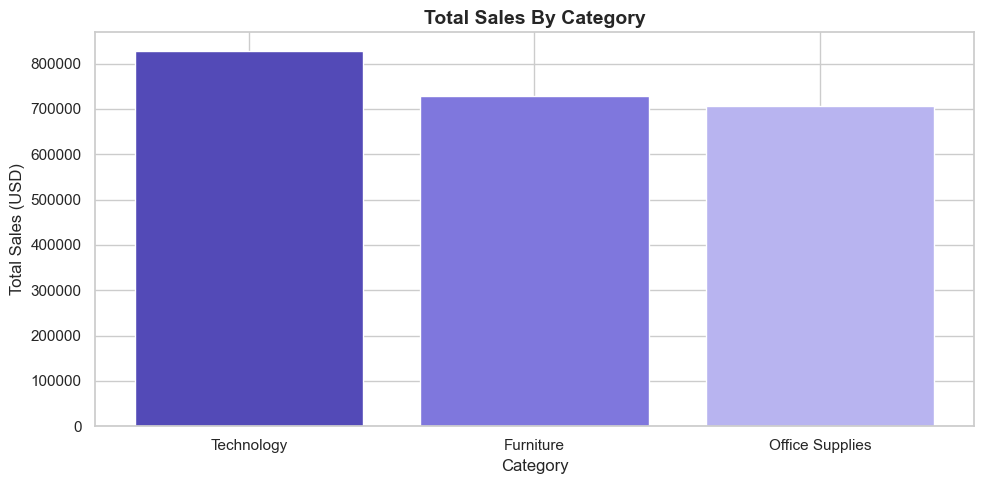

In [39]:
# step-1 group your data by category and add up all sales
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

# step -2 create a blank chart
fig, ax = plt.subplots()

# step-3 draw the bars
bars = ax.bar(category_sales.index, category_sales.values,color=['#534AB7', '#7F77DD', '#B8B4F0'])

# step-4 add the title and labels
ax.set_title('Total Sales By Category', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales (USD)')

plt.tight_layout()
plt.savefig('sales_by_category.png', dpi = 150)
plt.show()

### Insights From Chart 1:
Technology category leads total revenue, followed by furniture and office suppllies.
 
However, highest sales volume does not guarantee high profit - we explore this further in the coorelation heatmap
below.

### *Chart 2: Monthly Sales Trend*

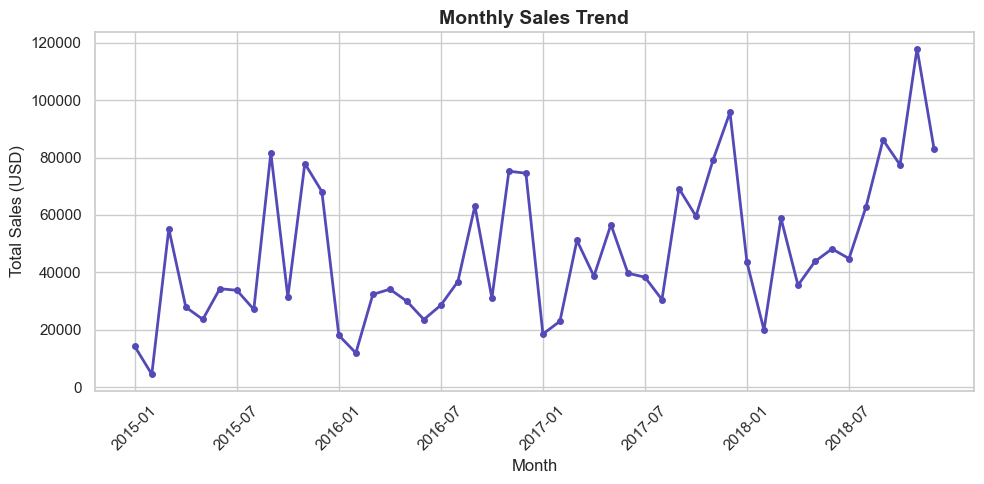

In [44]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M')

monthly = df.groupby('month')['sales'].sum()

fig, ax = plt.subplots()
ax.plot(monthly.index.astype(str), monthly.values,
        color='#534AB7', linewidth=2, marker='o', markersize = 4)

ax.set_title('Monthly Sales Trend', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (USD)')

# Only show every 6th labels so the x-axis stays readable
tick_positions = range(0, len(monthly), 6)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([monthly.index.astype(str)[i] for i in tick_positions], rotation=45)
# Note the above code is taken from claude ai because in normal code the x-axis is so messy
plt.tight_layout()
plt.savefig('Chart2_monthly_sales_trend.png', dpi = 150)
plt.show()

### Insights Chart 2:
Sales show a clear upward trend over the years with strong spike toward year-end Q4,
likely due to holiday season. This seasonality is important for inventory and marketing planning.

### *Chart 3: Sales Distribution With Outliers Overlay*

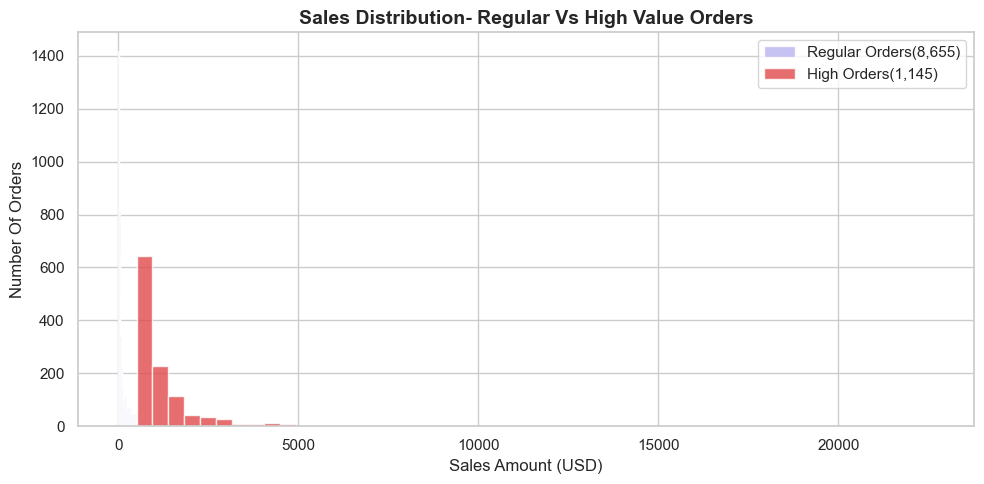

In [51]:
# Separate your data into two groups
regular = df[df['is_high_value'] == False]['sales']
high_value = df[df['is_high_value'] == True]['sales']

#creating a blank chart
fig,ax = plt.subplots()

# Draw histogram for regular orders
ax.hist(regular, bins=50, color='#B8B4F0',
        label=f'Regular Orders({len(regular):,})', alpha=0.8)

# Draw the histogram for high value orders
ax.hist(high_value, bins=50, color='#E24A4B',
        label=f'High Orders({len(high_value):,})',alpha = 0.8)

# labe, legend and save
ax.set_title('Sales Distribution- Regular Vs High Value Orders',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sales Amount (USD)')
ax.set_ylabel('Number Of Orders')
ax.legend()

plt.tight_layout()
plt.savefig('chart3_sales_distribution.png', dpi=150)
plt.show()


In [53]:
print("Max sale value:", df['sales'].max())
print("Max high-value order:", df[df['is_high_value'] == True]['sales'].max())
print("Top 5 highest orders:")
print(df['sales'].nlargest(5))

Max sale value: 22638.48
Max high-value order: 22638.48
Top 5 highest orders:
2697    22638.480
6826    17499.950
8153    13999.960
2623    11199.968
4190    10499.970
Name: sales, dtype: float64


### Insights From Chart 3:
Sales follows a right-skewed distribution - the majority of orders(8,655)
cluster below $1,000 while high-value orders (1145) extend up to $22,000+.

This mean small number of large orders significantly impact total revenue,
a critical insight for sales prioritization strategy 

### *Chart 4 - Correlation Heatmap*

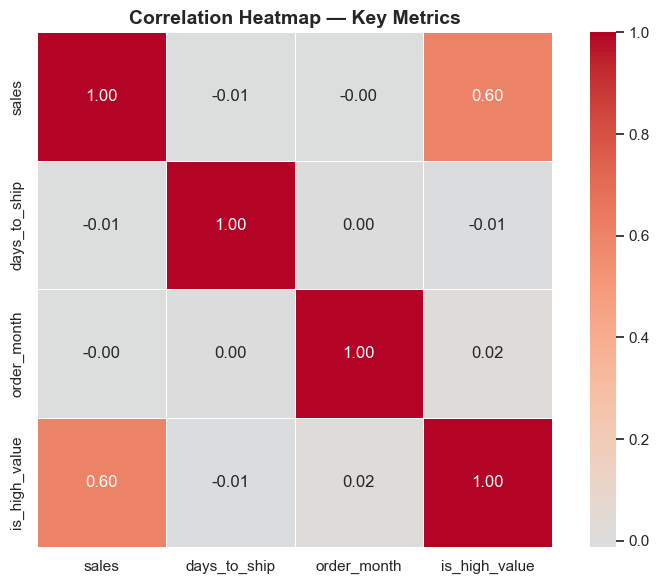

In [57]:
# Engineer useful numeric column from existing data.
df['order_month'] = df['order_date'].dt.month
df['order_year'] = df['order_date'].dt.year

# Now build correlation on what we have.
cols = ['sales', 'days_to_ship', 'order_month', 'is_high_value']

# is_high_value is a boolean column, convert it in to (0 and 1) for correlation.
df['is_high_value'] = df['is_high_value'].astype(int)

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax = ax , linewidths=0.5)
ax.set_title('Correlation Heatmap — Key Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_correlation_heatmap.png', dpi=150)
plt.show()

### Insight — Chart 4
Sales correlate strongly with is_high_value (expected — that column was 
derived from sales). More interestingly, days_to_ship shows minimal 
correlation with sales size — meaning large orders are not shipped faster 
than small ones, which could be a logistics improvement opportunity.
Order month shows slight correlation with sales, confirming the Q4 
seasonality spotted in Chart 2.

## **Project Summary**

**Dataset:** Superstore Sales (~9,800 rows after cleaning)  
**Tools:** Python, pandas, matplotlib, seaborn  

### Key Findings
1. Technology is the highest revenue category
2. Sales peak in Q4 every year — clear seasonality pattern
3. 11.7% of orders (1,145) are high-value and drive disproportionate revenue
4. Shipping time has zero correlation with order size — a logistics gap

### Data Limitations
This dataset does not include profit or discount columns.
Analysis focuses on sales volume, order timing, and shipping behaviour.